# Homework 2

## Problem 1 -  Dollar Profits
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols.
- dollarpos variable below is a DataFrame containing randomly generated initial dollar positions in each symbol at the close of market the prior day. 
- Compute the dollar profit in each symbol on a given day as a DataFrame
- Plot the cumulative dollar profit in A through time

In [97]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

dollarpos = np.random.normal(1000,100, (1000,5))
dollarpos = pd.DataFrame(dollarpos,columns = columns).abs()

In [98]:
dollar_profit= rets*dollarpos


In [99]:

cumulative_profit=dollar_profit.cumsum()

<Axes: >

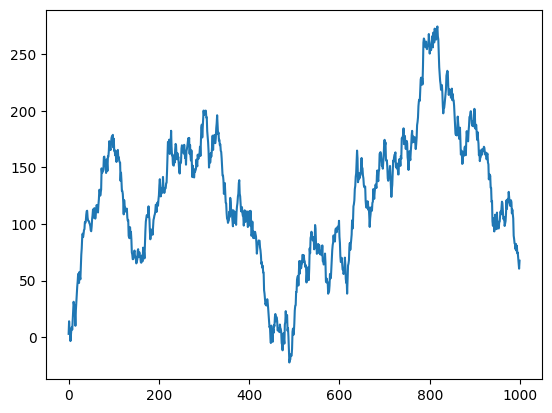

In [100]:
cumulative_profit['A'].plot()

In [101]:
dollar_profit

,A,B,C,D,E
0,2.938826,-1.904630,14.950204,-1.186875,0.973258
1,11.121520,-5.503108,-3.989497,1.435366,-1.871854
2,-7.234170,-0.953535,-1.992773,3.691496,-11.388611
3,-3.923976,6.730252,10.423097,-8.674680,3.844862
4,-6.326805,-6.177664,-4.526100,-2.082859,6.271965
...,...,...,...,...,...
995,0.685137,0.392251,11.069616,-6.095103,-5.001815
996,-4.911086,-8.817545,2.077400,-1.482040,-13.122420
997,-5.197121,-1.063285,1.332628,-3.061883,12.508481
998,-4.146210,5.460977,-12.329190,10.041536,-7.010774


In [102]:
rets.head()

,A,B,C,D,E
0,0.002978,-0.001886,0.015511,-0.001390,0.000889
1,0.010167,-0.005529,-0.003529,0.001380,-0.001880
2,-0.007315,-0.001092,-0.002062,0.004000,-0.010289
3,-0.004212,0.007451,0.011898,-0.009321,0.004261
4,-0.005979,-0.005199,-0.005294,-0.002463,0.006475


In [103]:
dollarpos.head()

,A,B,C,D,E
0,986.883892,1009.945713,963.855726,854.101435,1094.914353
1,1093.872669,995.278760,1130.634236,1039.967874,995.893444
2,988.909846,873.050137,966.428699,922.890901,1106.897311
3,931.551739,903.208327,876.001081,930.647464,902.428986
4,1058.200028,1188.182520,854.963604,845.612332,968.584335


## Problem 2 - Performance Stats 
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols.
- Please complete the function "compute_stats".
- compute_stats takes as input rets and returns a new DataFrame (stats) containing performance stats as specified below. rows of the result should be symbols and columns the performance stat label.
    1. "avg": average return (annualized)
    2. "vol": volatility (annualized)
    3. "sharpe": sharpe ratio (annualzied)
    4. "hit_rate": percent of returns which are positive
- Plot the sharpe ratios in "stats" in ascending order.

In [104]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

In [105]:
rets.mean()
stats = {}
stats['avg'] = rets.mean() * 252
stats['vol'] = rets.std() * np.sqrt(252)

In [106]:
def compute_stats(rets):
    stats = {}
    stats['avg'] = rets.mean() * 252
    stats['vol'] = rets.std() * np.sqrt(252)
    stats['sharpe'] = stats['avg'] / stats['vol']
    stats['hit_rate'] = (rets>0).sum()/rets.count()
    stats = pd.DataFrame(stats)
    # fill out the body here
    # return a DataFrame "stats"
    # columns should be performance stat label
    # rows should be symbols
    return stats

In [107]:
stats = compute_stats(rets)
stats

,avg,vol,sharpe,hit_rate
A,0.028730,0.101799,0.282224,0.521
B,0.120800,0.099772,1.210766,0.520
C,0.018690,0.103599,0.180409,0.514
D,0.051331,0.100662,0.509934,0.518
E,0.013511,0.101800,0.132720,0.513


<Axes: >

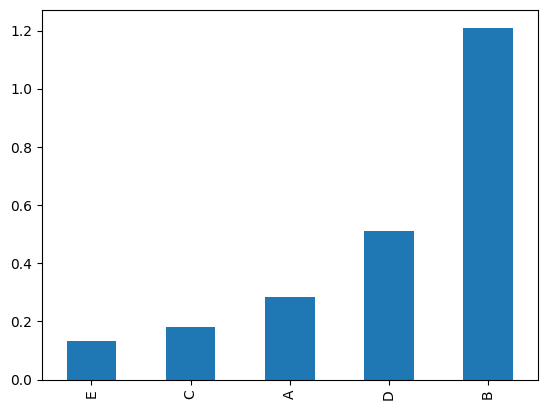

In [108]:
stats.sort_values('sharpe', ascending=True)['sharpe'].plot(kind='bar')


## Problem 3 - Simple Reversal Signal
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols
- Please complete the function "reversal_signal"
- reversal_signal takes as input rets and returns a new DataFrame (signal) which has the same rows/columns as rets. The values of signal are 1 if the symbol had the worst return that day, -1 if it had the best return, and 0 otherwise. 
- plot the value of signal through time for "A"

Hint: Try to construct a boolean DataFrame first and then convert it to an integer DataFrame

In [109]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

In [110]:
rets

,A,B,C,D,E
0,0.002978,-0.001886,0.015511,-0.001390,0.000889
1,0.010167,-0.005529,-0.003529,0.001380,-0.001880
2,-0.007315,-0.001092,-0.002062,0.004000,-0.010289
3,-0.004212,0.007451,0.011898,-0.009321,0.004261
4,-0.005979,-0.005199,-0.005294,-0.002463,0.006475
...,...,...,...,...,...
995,0.000698,0.000355,0.009889,-0.005684,-0.005408
996,-0.004135,-0.009947,0.002207,-0.001526,-0.011510
997,-0.005282,-0.001007,0.001393,-0.003495,0.011317
998,-0.004228,0.005018,-0.011916,0.009132,-0.006267


In [111]:
rets

,A,B,C,D,E
0,0.002978,-0.001886,0.015511,-0.001390,0.000889
1,0.010167,-0.005529,-0.003529,0.001380,-0.001880
2,-0.007315,-0.001092,-0.002062,0.004000,-0.010289
3,-0.004212,0.007451,0.011898,-0.009321,0.004261
4,-0.005979,-0.005199,-0.005294,-0.002463,0.006475
...,...,...,...,...,...
995,0.000698,0.000355,0.009889,-0.005684,-0.005408
996,-0.004135,-0.009947,0.002207,-0.001526,-0.011510
997,-0.005282,-0.001007,0.001393,-0.003495,0.011317
998,-0.004228,0.005018,-0.011916,0.009132,-0.006267


str

'D'

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


In [135]:
rets

,A,B,C,D,E
0,0.002978,-0.001886,0.015511,-0.001390,0.000889
1,0.010167,-0.005529,-0.003529,0.001380,-0.001880
2,-0.007315,-0.001092,-0.002062,0.004000,-0.010289
3,-0.004212,0.007451,0.011898,-0.009321,0.004261
4,-0.005979,-0.005199,-0.005294,-0.002463,0.006475
...,...,...,...,...,...
995,0.000698,0.000355,0.009889,-0.005684,-0.005408
996,-0.004135,-0.009947,0.002207,-0.001526,-0.011510
997,-0.005282,-0.001007,0.001393,-0.003495,0.011317
998,-0.004228,0.005018,-0.011916,0.009132,-0.006267


In [136]:
def reversal_signal(rets):
    signal = {}
    signal = rets
    for idx, row in signal.iterrows():
        worst = 0
        worst_col = ''
        best = 0
        best_col = ''
        for col in list(signal.columns):
            if best<row[col]:
                best = row[col]
                best_col=col
            if worst>row[col]:
                worst = row[col]
                worst_col = col

        for col in list(signal.columns):
            if col == best_col:
                signal.loc[idx, best_col] = -1
            if col == worst_col:
                signal.loc[idx, worst_col] = 1
            else:
                signal.loc[idx, col] = 0
                
        
        
        
    
    # fill out the body here
    # return a DataFrame "signal"
    # signal has same index/columns as rets
    # the value in signal is  1 if the symbol had the worst return on
    # a particular day, -1 if it had the best, and 0 otherwise
    return signal

In [137]:
signal = reversal_signal(rets)

In [138]:
signal

,A,B,C,D,E
0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,0.0
996,0.0,0.0,0.0,0.0,1.0
997,1.0,0.0,0.0,0.0,0.0
998,0.0,0.0,1.0,0.0,0.0


<Axes: >

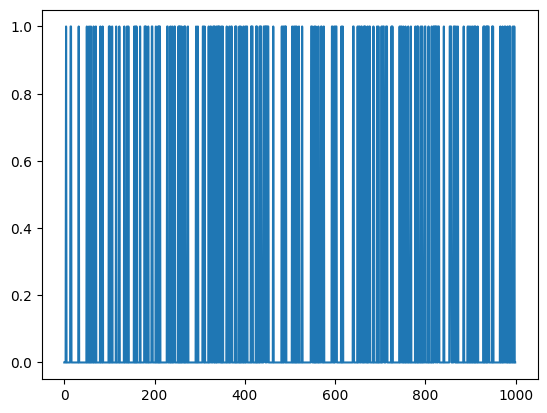

In [139]:
signal['A'].plot()